# New section

In [ ]:
!pip install timm
import timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.0/302.0 kB 39.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 58.9 MB/s eta 0:00:00


In [2]:
from fastai.vision.all import load_learner
import time

loaded_model = load_learner('/content/drive/MyDrive/modelre/resnet50re.pkl')

In [1]:
def ss(seconds):
    minutes = int(seconds) // 60
    sec = int(seconds) % 60
    return f"{minutes:02}:{sec:02}"

In [3]:
import os
from fastai.vision.all import PILImage
t0 = time.time()

test_dirs = ['/content/drive/MyDrive/downl', '/content/drive/MyDrive/data3/te/normal']
labels = ["injury", "normal"]
y_true = []
y_preds = []

for idx, test_dir in enumerate(test_dirs):
    for img_name in os.listdir(test_dir):
        img_path = os.path.join(test_dir, img_name)
        img = PILImage.create(img_path)
        pred_class, pred_idx, outputs = loaded_model.predict(img)
        y_preds.append(outputs[1].item())  # Store the probability of being 'injury'
        y_true.append(idx)  # 0 for injury, 1 for normal

print("Training time:", time.time()-t0)
print(ss(time.time()-t0))
time_per_image = (time.time() - t0) / 189
print("Time per image:", time_per_image, "seconds")

Training time: 85.88309097290039
01:25
Time per image: 0.45442504479140833 seconds


In [4]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

y_pred_labels = [1 if prob > 0.5 else 0 for prob in y_preds]

accuracy = accuracy_score(y_true, y_pred_labels)
precision = precision_score(y_true, y_pred_labels)
recall = recall_score(y_true, y_pred_labels)
f1 = f1_score(y_true, y_pred_labels)
roc_auc = roc_auc_score(y_true, y_preds)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"ROC AUC: {roc_auc}")



Accuracy: 0.9894179894179894
Precision: 0.9897959183673469
Recall: 0.9897959183673469
F1-Score: 0.9897959183673469
ROC AUC: 0.9985422740524782


In [5]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_labels)


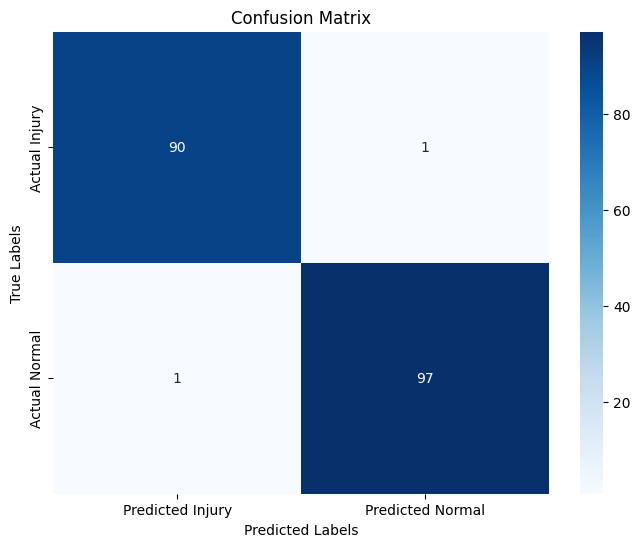

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=['Predicted Injury', 'Predicted Normal'],
            yticklabels=['Actual Injury', 'Actual Normal'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


In [7]:
tn, fp, fn, tp = confusion_matrix(y_true, y_pred_labels).ravel()
specificity = tn / (tn + fp)
#True Negative (TN): Number of images correctly classified as 'normal'.
#False Positive (FP): Number of 'normal' images incorrectly classified as 'injury'.
print(f"Specificity: {specificity}")

Specificity: 0.989010989010989


# New section

In [ ]:
loaded_model2 = load_learner('/content/drive/MyDrive/pklmodel/efficientnetv2_s.pkl')

In [ ]:
t1 = time.time()

test_dirs = ['/content/drive/MyDrive/data3/te/injury', '/content/drive/MyDrive/data3/te/normal']
labels = ["injury", "normal"]
y_true = []
y_preds = []

for idx, test_dir in enumerate(test_dirs):
    for img_name in os.listdir(test_dir):
        img_path = os.path.join(test_dir, img_name)
        img = PILImage.create(img_path)
        pred_class, pred_idx, outputs = loaded_model2.predict(img)
        y_preds.append(outputs[1].item())  # Store the probability of being 'injury'
        y_true.append(idx)  # 0 for injury, 1 for normal

print("Testing time:", time.time()-t1)
print(ss(time.time()-t0))
time_per_image = (time.time() - t0) / 189
print("Time per image:", time_per_image, "seconds")